In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.max_columns = None

In [15]:
df = pd.read_excel('data2.xlsx')

feats = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5', 'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 
            'S2K_item_9', 'S2K_item_10', 'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14', 'S2K_item_15', 'S2K_item_16', 
            'S2K_item_17', 'S2K_item_18', 'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22', 'S2K_item_23', 'S2K_item_24']

labels = ['Cumulative_prednisolone_intake_daily_category',
        'Number_mod_severe_drugs','Drug_use_score1',
        'Drug_use_score2', 'Delta_treatment_score']




In [16]:
scaler = MinMaxScaler()

features = df.loc[:, feats]
features = features.apply(lambda x: x / 100)
targets = df.loc[:, labels]
targets = pd.DataFrame(scaler.fit_transform(targets))

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, shuffle=True, random_state=42)

In [22]:
predn_rf = RandomForestRegressor(random_state=42)
sev_drugs_rf = RandomForestRegressor(random_state=42)
du_sc1_rf = RandomForestRegressor(random_state=42)
du_sc2_rf = RandomForestRegressor(random_state=42)
delta_treat_rf = RandomForestRegressor(random_state=42)


regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
reg_names = labels

def regressions():
    losses = {}
    importances = {}
    for i, name in zip(range(len(regressors)), reg_names):
        regressors[i].fit(X_train, y_train[i])
        preds = regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        importances[name] = regressors[i].feature_importances_
        losses[name] = loss

    return losses, importances

classification = regressions()
classification

({'Cumulative_prednisolone_intake_daily_category': 0.09669244650786371,
  'Number_mod_severe_drugs': 0.022141884293824455,
  'Drug_use_score1': 0.016803952337347883,
  'Drug_use_score2': 0.007267867524986352,
  'Delta_treatment_score': 0.004978218998972198},
 {'Cumulative_prednisolone_intake_daily_category': array([0.00405702, 0.02125082, 0.00082997, 0.02266431, 0.06766245,
         0.00643057, 0.01112394, 0.02082026, 0.08141249, 0.01238464,
         0.01542448, 0.05261792, 0.11135928, 0.02754431, 0.07612639,
         0.05719971, 0.05208214, 0.03573015, 0.03714111, 0.07750451,
         0.06256135, 0.02085122, 0.08196464, 0.04325631]),
  'Number_mod_severe_drugs': array([0.0065258 , 0.0082126 , 0.01611435, 0.00819837, 0.01902121,
         0.00931744, 0.01102443, 0.035493  , 0.09076521, 0.00630376,
         0.01429184, 0.03413289, 0.10426384, 0.0288722 , 0.11570705,
         0.06339922, 0.06285858, 0.01988548, 0.0294353 , 0.07863035,
         0.08884649, 0.02747973, 0.0712866 , 0.0499342

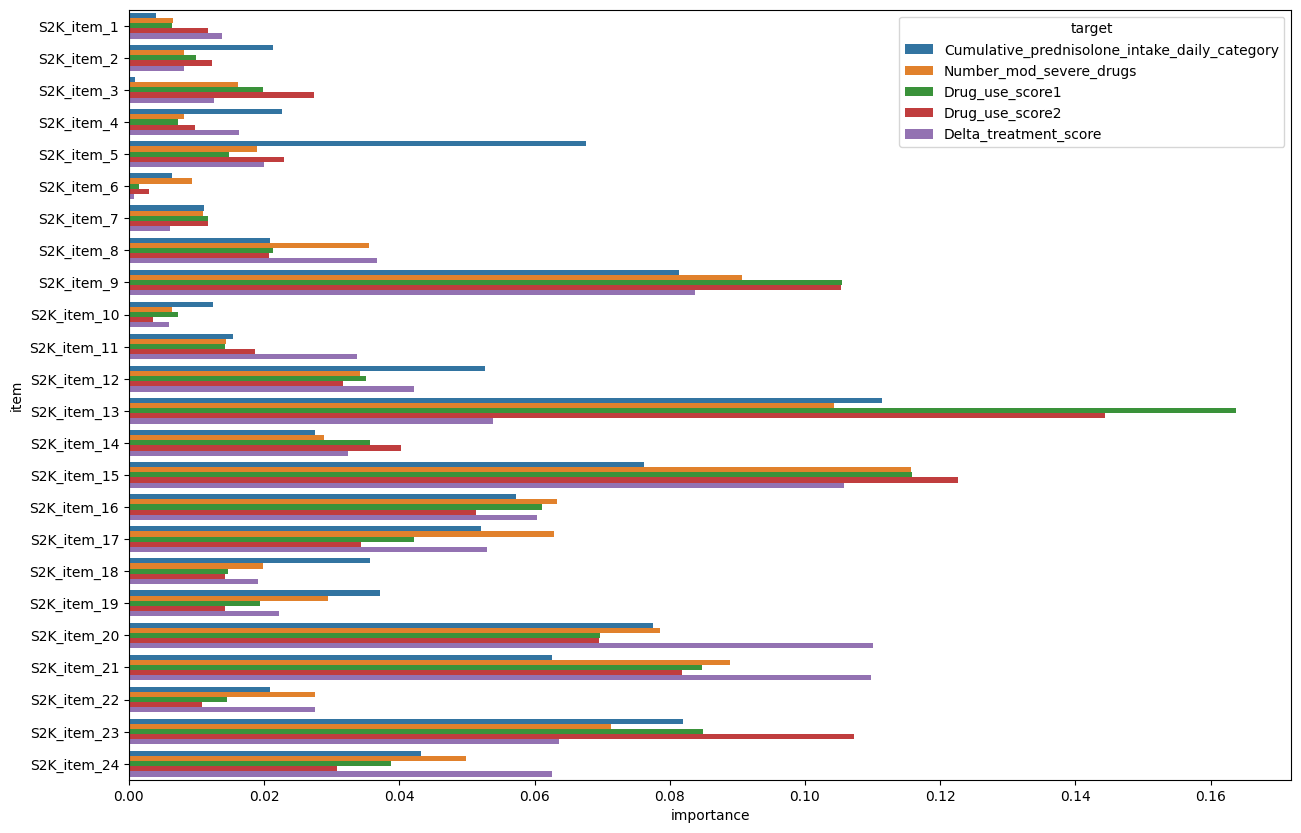

In [23]:
import re

importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

plt.figure(figsize=(15,10))
sns.barplot(melted,x='importance',y='item', hue='target')
plt.show()


({'Cumulative_prednisolone_intake_daily_category': 0.0916809376494441, 'Number_mod_severe_drugs': 0.021326519639191917, 'Drug_use_score1': 0.015777994850286713, 'Drug_use_score2': 0.0065395426272338575, 'Delta_treatment_score': 0.004606798208769009}, {'Cumulative_prednisolone_intake_daily_category': array([0.00184439, 0.03330335, 0.        , 0.03613885, 0.09660552,
       0.01167271, 0.01895114, 0.014296  , 0.04419835, 0.01901191,
       0.01501163, 0.05258831, 0.14634602, 0.03277106, 0.03271914,
       0.03100887, 0.01819443, 0.0648589 , 0.04535589, 0.10450114,
       0.01134255, 0.03022605, 0.10918684, 0.02986701], dtype=float32), 'Number_mod_severe_drugs': array([0.0189471 , 0.00164725, 0.0388056 , 0.00821936, 0.0157544 ,
       0.01631534, 0.00924652, 0.03187879, 0.02841694, 0.01628878,
       0.        , 0.03948665, 0.21999359, 0.0285533 , 0.06124102,
       0.02009578, 0.04166922, 0.01378966, 0.03934379, 0.10942239,
       0.05584484, 0.05425726, 0.10239248, 0.02838998], dtype=fl

<AxesSubplot: xlabel='importance', ylabel='item'>

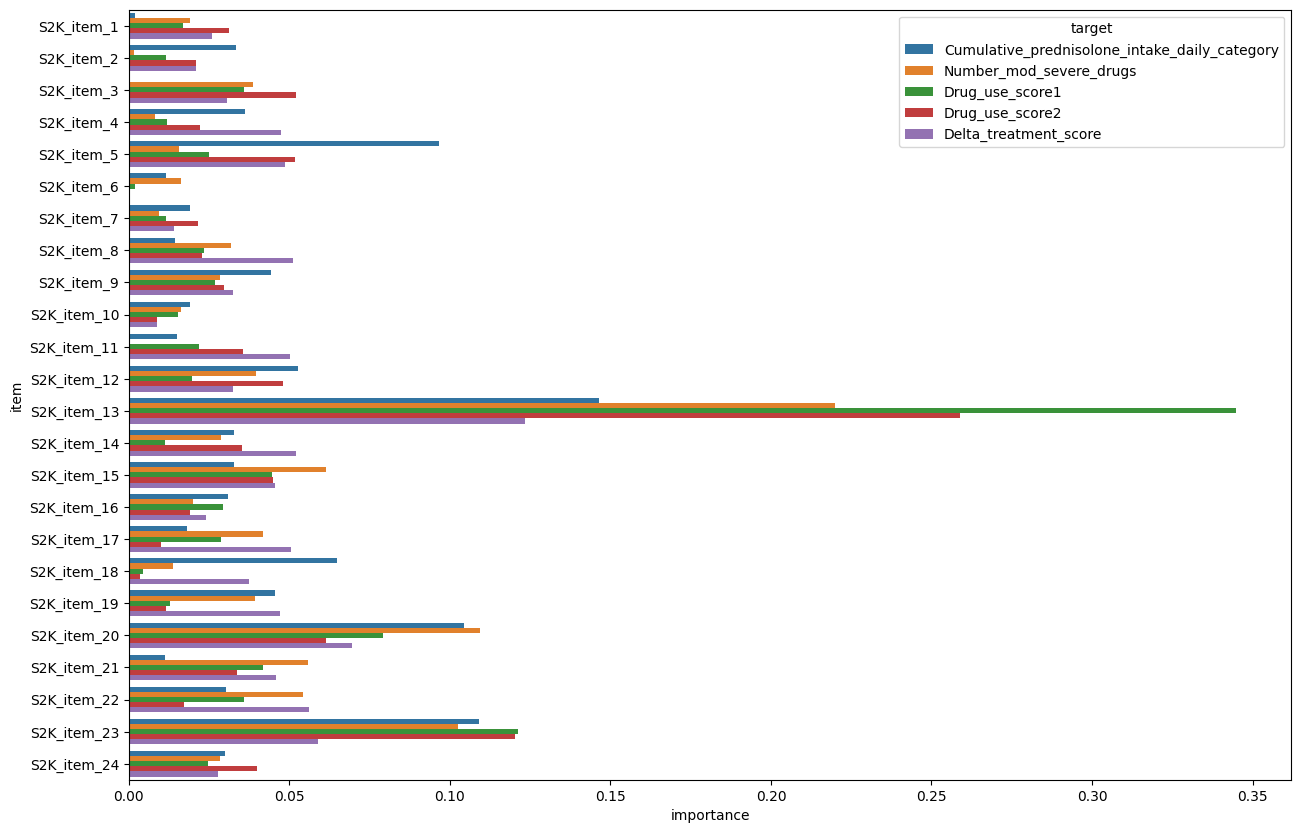

In [28]:
import xgboost

predn_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sev_drugs_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc1_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc2_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
delta_treat_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


xgb_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
xgb_reg_names = labels

def xgb():
    losses = {}
    imps = {}
    for i, name in zip(range(len(xgb_regressors)), xgb_reg_names):
        xgb_regressors[i].fit(X_train, y_train[i])
        preds = xgb_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        imps[name] = xgb_regressors[i].feature_importances_
        losses[name] = loss

    return losses, imps

classification = xgb()
print(classification)

importances_df = pd.DataFrame(xgb()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))

plt.figure(figsize=(15,10))

sns.barplot(melted,x='importance',y='item', hue='target')


({'Cumulative_prednisolone_intake_daily_category': 0.09261185732533436, 'Number_mod_severe_drugs': 0.02094222959851816, 'Drug_use_score1': 0.01563728390600382, 'Drug_use_score2': 0.006486590743121926, 'Delta_treatment_score': 0.004655184299691296}, {'Cumulative_prednisolone_intake_daily_category': array([ 0.        , 13.12823444,  0.        , 10.45690868, 44.01039983,
       -0.        ,  0.        ,  5.04102798,  7.71072242,  3.92010512,
        0.        , 16.20398085, 19.93004712,  4.62559741,  6.7555388 ,
        7.75771835, -2.04143043, 17.80944271, 16.88909558,  8.41939884,
        3.70240213,  5.66100314, 22.76800039,  0.        ]), 'Number_mod_severe_drugs': array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ,
       -0.        , -0.        ,  6.55952255,  0.        , -0.        ,
        0.        , -0.7565576 , -0.        , -0.        ,  1.01914507,
        0.        , -0.        ,  3.0

<AxesSubplot: xlabel='importance', ylabel='item'>

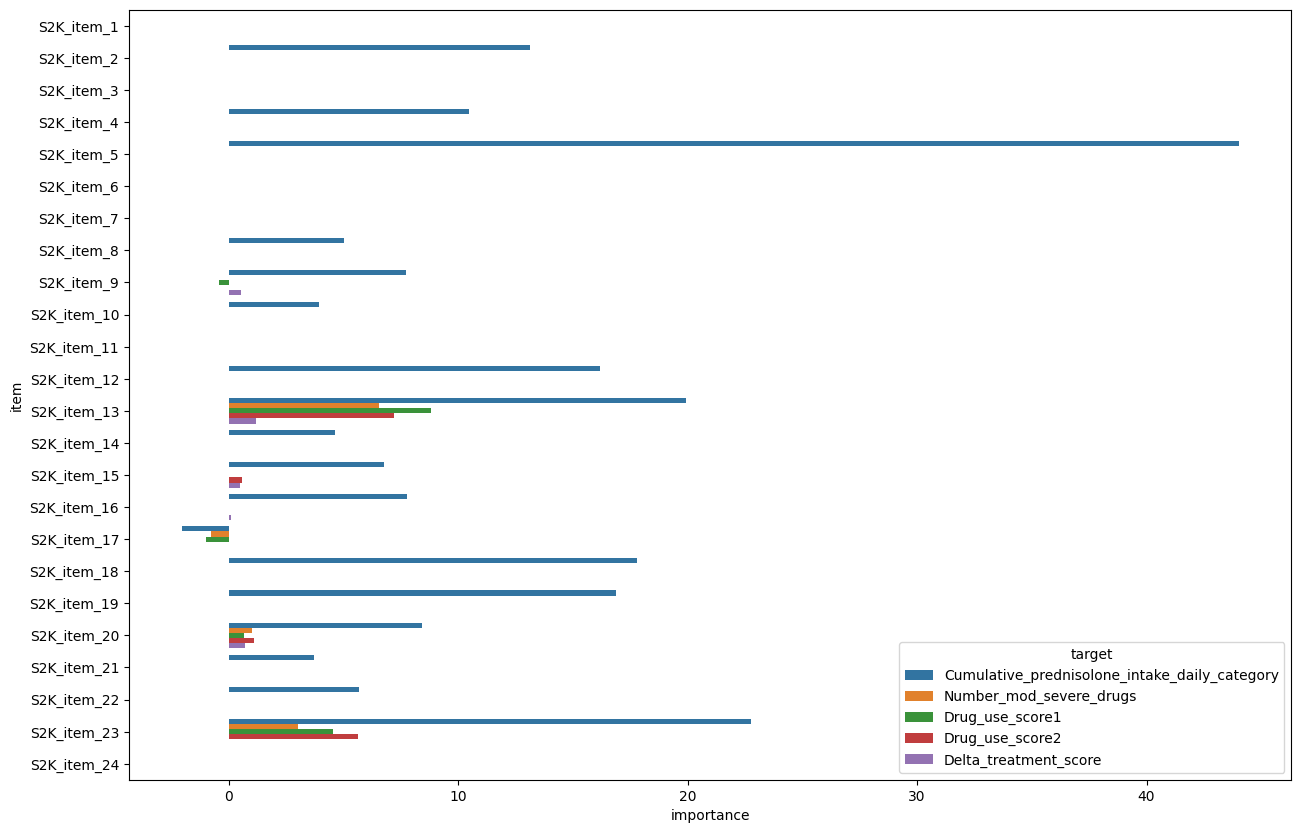

In [32]:
from sklearn.linear_model import Lasso

predn_rf = Lasso(alpha=0.00001, random_state=42)
sev_drugs_rf = Lasso(alpha=0.00001, random_state=42)
du_sc1_rf = Lasso(alpha=0.00001, random_state=42)
du_sc2_rf = Lasso(alpha=0.00001, random_state=42)
delta_treat_rf = Lasso(alpha=0.00001, random_state=42)


lasso_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
lasso_reg_names = labels

def lasso():
    losses = {}
    coefs = {}
    for i, name in zip(range(len(lasso_regressors)), lasso_reg_names):
        lasso_regressors[i].fit(X_train, y_train[i])
        preds = lasso_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        coefs[name] = lasso_regressors[i].coef_
        losses[name] = loss

    return losses, coefs

classification = lasso()
print(classification)
# print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')


importances_df = pd.DataFrame(lasso()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
# melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))
plt.figure(figsize=(15,10))

sns.barplot(melted,x='importance',y='item', hue='target')


({'Cumulative_prednisolone_intake_daily_category': 0.09450540731923592, 'Number_mod_severe_drugs': 0.021060524279415557, 'Drug_use_score1': 0.015827074452107178, 'Drug_use_score2': 0.006524879789976679, 'Delta_treatment_score': 0.004616300213108613}, {'Cumulative_prednisolone_intake_daily_category': array([ 0.        ,  1.79605334,  0.        ,  1.33537261,  6.128566  ,
       -0.        ,  1.01612811,  1.75235873,  6.74521376,  1.03272431,
        2.85976887,  7.63791063, 11.44581009,  3.24753249,  5.90101531,
        5.2017145 , -0.74752214,  4.53023724,  5.17414042,  7.71241421,
        4.28470901,  2.48913352, 11.54085602,  1.11814522]), 'Number_mod_severe_drugs': array([ 0.        ,  0.        ,  0.        ,  0.        , -0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ,
       -0.        ,  0.        ,  3.74094846,  0.        , -0.        ,
        0.01977985, -0.90045361, -0.        , -0.        ,  1.17410386,
        0.26614135, -0.32409185,  2

<AxesSubplot: xlabel='importance', ylabel='item'>

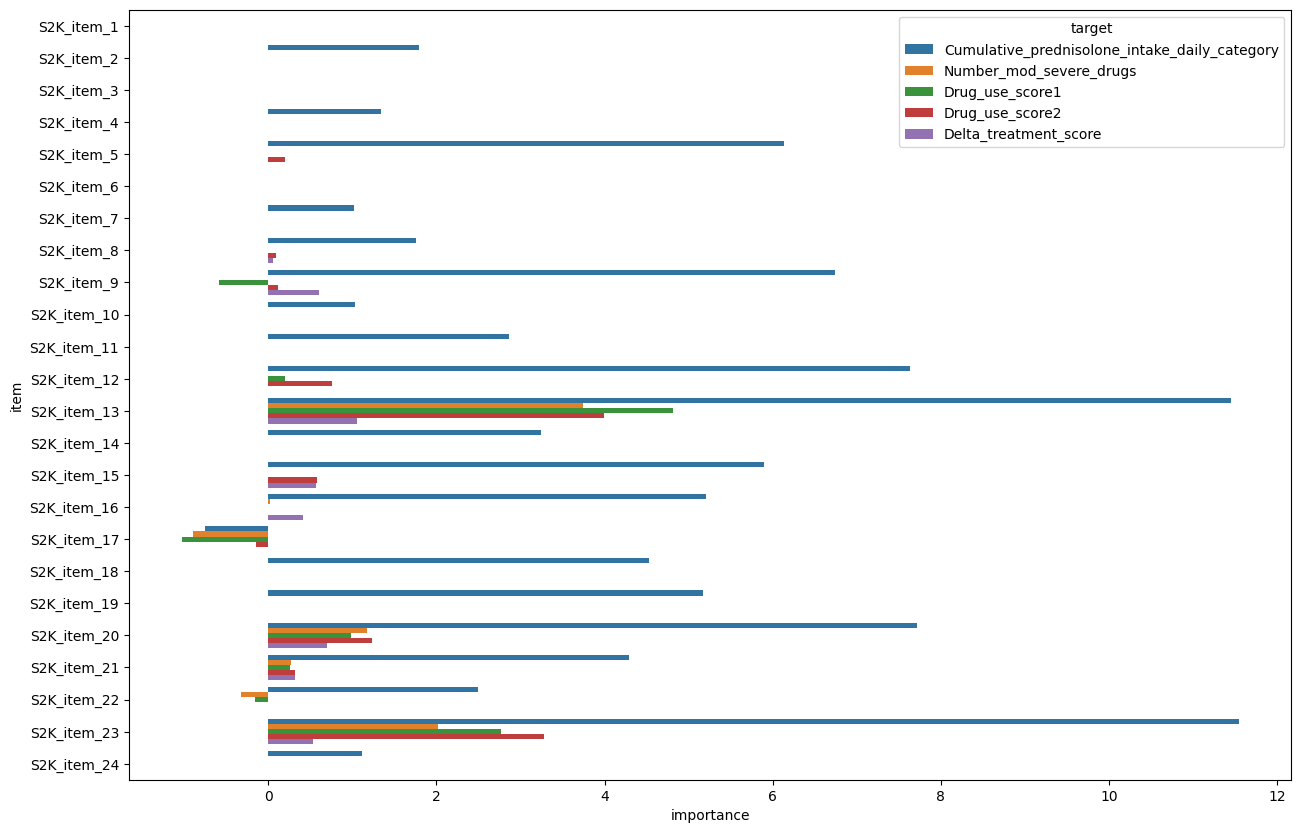

In [33]:
from sklearn.linear_model import ElasticNet

predn_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
sev_drugs_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
du_sc1_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
du_sc2_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
delta_treat_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)


elastic_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
elastic_reg_names = labels


def elastic():
    losses = {}
    imps = {}
    for i, name in zip(range(len(elastic_regressors)), elastic_reg_names):
        elastic_regressors[i].fit(X_train, y_train[i])
        preds = elastic_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[i], preds)
        imps[name] = elastic_regressors[i].coef_
        losses[name] = loss

    return losses, imps

classification = elastic()
# print(f'PGA loss: {classification[0]["PGA"]}\nGC loss: {classification[0]["GC"]}')
print(classification)

importances_df = pd.DataFrame(elastic()[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']
melted['item'] = melted.item.apply(lambda x: re.sub(r'time_adj_|_percentage_followup','',x))
plt.figure(figsize=(15,10))

sns.barplot(melted,x='importance',y='item', hue='target')